# Final Project, Part 2 & 3

---
**Name:** Matthew Zheng  
**Group Size:** 1 (Individual)
---

## Code:


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import altair as alt
from vega_datasets import data

alt.data_transformers.disable_max_rows()

df = pd.read_csv("C://Users/mzhen/Desktop/School/IS445/202507-divvy-tripdata.csv")
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,455D43BD91D73437,classic_bike,2025-07-05 17:15:08.456,2025-07-05 17:25:47.079,Lincoln Ave & Diversey Pkwy,CHI00285,Lincoln Ave & Addison St,CHI00478,41.932225,-87.658617,41.946176,-87.673308,member
1,9D4A6B723ECD98CA,classic_bike,2025-07-01 13:57:38.878,2025-07-01 14:06:35.780,Cottage Grove Ave & Oakwood Blvd,CHI00400,Cottage Grove Ave & 47th St,CHI00488,41.822985,-87.607100,41.809855,-87.606755,member
2,C57044CF523302ED,classic_bike,2025-07-31 16:49:28.142,2025-07-31 17:15:28.999,Theater on the Lake,CHI00420,Winthrop Ave & Lawrence Ave,CHI00391,41.926277,-87.630834,41.968812,-87.657659,member
3,AFD35552E6685B6E,electric_bike,2025-07-17 09:36:21.058,2025-07-17 09:46:54.706,Pine Grove Ave & Waveland Ave,CHI00354,Winthrop Ave & Lawrence Ave,CHI00391,41.949473,-87.646453,41.968812,-87.657659,member
4,C0582EBAA6CED519,classic_bike,2025-07-02 18:43:45.213,2025-07-02 18:57:06.687,Theater on the Lake,CHI00420,Sheffield Ave & Wellington Ave,CHI00274,41.926277,-87.630834,41.936253,-87.652662,member


In [2]:
#convert to datetime
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at'] = pd.to_datetime(df['ended_at'])

print(df['started_at'].head())
print(df['ended_at'].head())

0   2025-07-05 17:15:08.456
1   2025-07-01 13:57:38.878
2   2025-07-31 16:49:28.142
3   2025-07-17 09:36:21.058
4   2025-07-02 18:43:45.213
Name: started_at, dtype: datetime64[us]
0   2025-07-05 17:25:47.079
1   2025-07-01 14:06:35.780
2   2025-07-31 17:15:28.999
3   2025-07-17 09:46:54.706
4   2025-07-02 18:57:06.687
Name: ended_at, dtype: datetime64[us]


In [3]:
#extract hour from started_at

df['hour'] = df['started_at'].dt.hour
df['hour']

0         17
1         13
2         16
3          9
4         18
          ..
763427    17
763428    11
763429    23
763430    14
763431    20
Name: hour, Length: 763432, dtype: int32

In [4]:
#calc ride duration (minutes)
df['duration_mins'] = ( df['ended_at'] - df['started_at'] ).dt.total_seconds() / 60

df['duration_mins']

0         10.643717
1          8.948367
2         26.014283
3         10.560800
4         13.357900
            ...    
763427    13.616867
763428    86.498600
763429     8.536600
763430    18.144350
763431    15.155100
Name: duration_mins, Length: 763432, dtype: float64

count    763432.000000
mean         18.005303
std          61.422130
min           0.001417
25%           5.973879
50%          10.455900
75%          18.287254
max        1500.896883
Name: duration_mins, dtype: float64

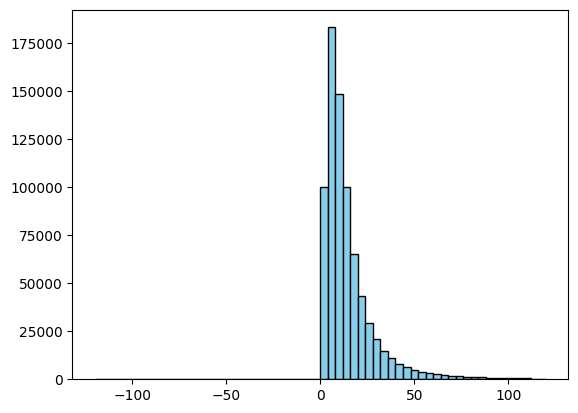

In [5]:
#print(df[df['duration_mins'] < 0])

plt.hist(df['duration_mins'], bins=60, range=(-120, 120), color='skyblue', edgecolor='black') # inspect distribution of ride duration (mins)
# count = (df['duration_mins'] > 2880).sum()

df['duration_mins'].describe()

#### Dataset Notes & Divvy Policy

The [dataset](https://divvybikes.com/system-data) has been processed to exclude the following:

* **Service & Maintenance:** Trips taken by staff for system inspection and servicing.
* **False Starts:** Any trips shorter than **60 seconds** (e.g., users re-docking to ensure a bike is secure).

### [Divvy Day Pass Policy](https://divvybikes.com/pricing/day-pass)

**Classic Bikes**
* **Time Limit:** 3 hours per individual ride.
* **Overtime Fee:** $0.20 per minute after 3 hours.
* **Pro-Tip:** To avoid fees, dock your bike before the 3-hour mark and check out a different one to "reset" your time.

**Ebikes**
* **Rate:** $0.44 per minute (at all times).

In [6]:
#Data Cleaning

df = df.dropna(subset=['start_station_name'])
df = df[df['duration_mins'] <= 1440] #remove trips longer than 24 hours because you can only rent up to 24 hours per day 

df['duration_mins'].describe()


count    588925.000000
mean         17.282547
std          34.371754
min           0.002200
25%           6.303783
50%          10.885133
75%          19.215250
max        1439.764433
Name: duration_mins, dtype: float64

In [7]:
#Top 20 stations for readibility

top_stations = (
    df.groupby('start_station_name')
    .size()
    .reset_index(name='ride_count')
    .sort_values('ride_count', ascending=False)
    .head(20)
)

# top_stations

df_top = df[df['start_station_name'].isin(top_stations['start_station_name'])]

In [8]:
# import vegafusion 
# alt.data_transformers.enable("vegafusion")
df_station_counts = (
    df_top.groupby('start_station_name')
    .size()
    .reset_index(name='ride_count')
    .sort_values('ride_count', ascending=False)
)

station_selection = alt.selection_point(
    fields=['start_station_name'],
    empty= False
)

color = alt.condition(
    station_selection,
    alt.value('blue'),
    alt.value('lightblue')
)

driver = alt.Chart(df_station_counts).mark_bar().encode(
    x=alt.X('ride_count:Q', title='Number of Rides'),
    y=alt.Y('start_station_name:N', sort='-x', title='Start Station'),
    color=color,
    tooltip=[
        alt.Tooltip('start_station_name:N', title='Station'),
        alt.Tooltip('ride_count:Q', title='Total Rides')
    ]
).add_params(station_selection).properties(
    width=250,
    height=450,
    title='Top 20 Busiest Divvy Start Stations (click to select station)'
)

driver


alt.Chart(...)

In [21]:
df_hourly = (
    df_top.groupby(['start_station_name', 'hour'])
    .size()
    .reset_index(name='ride_count')
)

# driven_preview = alt.Chart(df_hourly).mark_bar(color='gray').encode(
#     x=alt.X('hour:O', title='Hour of Day'),
#     y=alt.Y('ride_count:Q', title='Number of Rides'),
#     tooltip=[
#         alt.Tooltip('hour:O', title='Hour'),
#         alt.Tooltip('ride_count:Q', title='Rides')
#     ]
# ).properties(width=400, height=450)

# driven_preview

max_rides = df_hourly['ride_count'].max()

driven = alt.Chart(df_hourly).mark_bar(color='lightblue', clip=True).encode(
    x=alt.X(
        'hour:O',
        title='Hour of Day',
        scale=alt.Scale(domain=list(range(24)), paddingInner=0.1),
    ),
    y=alt.Y(
    'sum(ride_count):Q', 
    title='Number of Rides',
    scale=alt.Scale(domain=[0, max_rides])
    ),
    tooltip=[
        alt.Tooltip('hour:O', title='Hour'),
        alt.Tooltip('ride_count:Q', title='Rides')
    ]
).transform_filter(
    station_selection
).properties(
    width=alt.Step(13),
    height=450,
    title='Number of Rides by Hour of day per Selected Station'
)

dashboard = driver | driven
dashboard


alt.HConcatChart(...)

In [22]:
df_top_short = df_top[df_top['duration_mins'] <= 120].copy()

df_top_short['duration_bin'] = pd.cut(
    df_top_short['duration_mins'],
    bins=24,
    precision=0
)
df_top_short['duration_bin_left'] = df_top_short['duration_bin'].apply(lambda x: round(x.left)).astype(int)

df_heat = (
    df_top_short.groupby(['start_station_name', 'hour', 'duration_bin_left'])
    .size()
    .reset_index(name='ride_count')
)

heatmap = alt.Chart(df_heat).mark_rect().encode(
    x=alt.X('hour:O', title='Hour of Day'),
    y=alt.Y('duration_bin_left:O', title='Ride Duration (minutes)', sort='descending'),
    color=alt.Color(
    'ride_count:Q',
    title='Number of Rides',
    scale=alt.Scale(scheme='greens') 
    ),
    tooltip=[
        alt.Tooltip('hour:O', title='Hour'),
        alt.Tooltip('duration_bin_left:O', title='Duration (min)'),
        alt.Tooltip('ride_count:Q', title='Rides')
    ]
).transform_filter(
    station_selection
).properties(
    width=400,
    height=450,
    title='Ride Duration by Hour for Selected Station'
)

top_row = driver | driven
dashboard = top_row & heatmap

dashboard = alt.vconcat(
    top_row,
    heatmap
).resolve_legend(color='independent')

dashboard.save('divvy_dashboard.json')

In [ ]:

# chicago geojson
import urllib.request, json
url = 'https://raw.githubusercontent.com/blackmad/neighborhoods/master/chicago.geojson'
with urllib.request.urlopen(url) as response:
    chicago_geojson = json.load(response)

chicago = alt.Data(values=chicago_geojson['features'])

background = alt.Chart(chicago).mark_geoshape(
    fill='lightgray',
    stroke='white'
).project(
    type='mercator',
    center=[-87.63, 41.89], 
    scale=80000  # zoom in 
).properties(width=400, height=500)

# top 20 stations with coords
top_stations_geo = (
    df_top.groupby('start_station_name')
    .agg(
        ride_count=('ride_id', 'count'),
        start_lat=('start_lat', 'first'),
        start_lng=('start_lng', 'first')
    )
    .reset_index()
    .sort_values('ride_count', ascending=False)
)

points = alt.Chart(top_stations_geo).mark_circle(color='steelblue', opacity=0.8).encode(
    longitude='start_lng:Q',
    latitude='start_lat:Q',
    size=alt.Size(
        'ride_count:Q',
        title='Number of Rides',
        scale=alt.Scale(range=[50, 800])
    ),
    tooltip=[
        alt.Tooltip('start_station_name:N', title='Station'),
        alt.Tooltip('ride_count:Q', title='Total Rides')
    ]
).project('mercator')

map_chart = (background + points).properties(
    title='Top 20 Busiest Divvy Start Stations in Chicago'
)

map_chart
map_chart.save('divvy_map.json')

In [ ]:
# Member vs Casual
member_counts = df['member_casual'].value_counts().reset_index()
member_counts.columns = ['rider_type', 'count']
member_counts['pct'] = member_counts['count'] / member_counts['count'].sum()

donut = alt.Chart(member_counts).mark_arc(innerRadius=50).encode(
    theta=alt.Theta('count:Q'),
    color=alt.Color('rider_type:N', title='Rider Type'),
    tooltip=[
        alt.Tooltip('rider_type:N', title='Rider Type'),
        alt.Tooltip('count:Q', title='Total Rides'),
        alt.Tooltip('pct:Q', title='Percentage', format='.1%')
    ]
).properties(
    width=300,
    height=300,
    title='Member vs Casual Riders'
)

text = alt.Chart(member_counts).mark_text(radius=85, size=14).encode(
    theta=alt.Theta('count:Q', stack=True),
    text=alt.Text('pct:Q', format='.1%'),
    color=alt.value('white')
)

donut_chart = (donut + text).properties(
    width=300,
    height=300,
    title='Member vs Casual Riders'
)

donut_chart
donut_chart.save('divvy_donut.json')

## Prose:

* One paragraph explaining how to use the dashboard you created, to help someone who is not an expert understand your dataset.
* A list of 1 or more contextual datasets you have identified, links to where they reside, and a sentence about why they might be useful in telling the final story.
   * by "contextual dataset" here means a dataset that would add context to your chosen dataset. For example, if your dataset is the Champaign bus routes, some interesting contextual datasets could be the Chicago bus routes, or the Springfield bus routes, or the Amtrak routes in Champaign
   * you do not have to do anything with this dataset at the moment beyond writing a bit about why it would be useful. Looking forward, you will want to include "contextual visualizations" (which you may or may not generate on your own) in your Final Project, Part 3 and identifying a possibly useful dataset is a great way to start looking for contextual visualizations.
* If you have identified your dataset as a "large one" (i.e. larger than the GitHub file upload limit) comment on if you want to revise your plan for hosting this data or not. If this does not apply to your dataset please explicitly state this.

## How to Use This Dashboard

This dashboard explores Divvy bike share ride data from Chicago, allowing you to investigate 
when and where people are renting bikes across the city's busiest stations. The **left chart** 
displays the top 20 most popular starting stations, ranked by total number of rides. The longer 
the bar, the more rides started at that station. To use the dashboard, simply **click on any bar** 
in the left chart to select a station, and the **right chart** will automatically update to show 
the hourly ride patterns for that specific station throughout the day, with hour `0` representing 
midnight and hour `12` representing noon. This allows you to explore questions like:

- Do rides at **commuter stations** peak during morning and evening rush hours?


You can click a different bar at any time to compare patterns across stations, and clicking the 
same bar again will deselect it and return the right chart to the overall hourly distribution 
across all top stations. Together, the two charts reveal patterns in both **where** Chicagoans 
and visitors choose to start their rides, and **what times of day** see the heaviest bike share 
activity.

---
## Contextual Datasets

The following dataset would add useful geographic context to this analysis:

- **Chicago Neighborhoods GeoJSON** - [Chicago Data Portal](https://data.cityofchicago.org/Facilities-Geographic-Boundaries/Boundaries-Neighborhoods/bbvz-uum9)
  
  This dataset contains the geographic boundaries of Chicago's neighborhoods as a GeoJSON file. 
  Combined with the latitude and longitude coordinates in the Divvy dataset, it would allow us 
  to map the top 20 stations as dots on a neighborhood map with dot size scaled to ride volume 
  revealing whether high-usage stations cluster in particular neighborhoods, tourist areas, or 
  commuter corridors.

---

## Data Hosting Plan

The full Divvy trip dataset for July 2025 exceeds GitHub's 100MB file upload limit and therefore 
cannot be hosted directly in this repository. Per the 
[Divvy Data License Agreement](https://divvybikes.com/data-license-agreement), the data may not 
be redistributed as a standalone dataset. Out of an abundance of caution, we forgo using Git LFS 
and instead link directly to the original source hosted on Divvy's public AWS S3 bucket below:

**Link to Data:** https://divvy-tripdata.s3.amazonaws.com/202507-divvy-tripdata.zip


## Plot Summary

Summarize the characteristics of the dataset in words: what does it represent, what are the fields/columns/rows, what data types are they, etc.

#### Dataset Summary

This dataset contains individual Divvy bike share trip records from **July 2025** in Chicago, 
Illinois, operated by Lyft under the City of Chicago's Divvy bicycle sharing service. Each 
**row** represents a single bike ride, and the dataset contains the following **columns**:

| Column | Data Type | Description |
|--------|-----------|-------------|
| `ride_id` | String | Unique identifier for each ride |
| `rideable_type` | Categorical | Type of bike (e.g. classic_bike, electric_bike) |
| `started_at` | Datetime | Date and time the ride began |
| `ended_at` | Datetime | Date and time the ride ended |
| `start_station_name` | String | Name of the station where the ride started |
| `start_station_id` | String | Unique ID of the start station |
| `end_station_name` | String | Name of the station where the ride ended |
| `end_station_id` | String | Unique ID of the end station |
| `start_lat` | Float | Latitude coordinate of the start station |
| `start_lng` | Float | Longitude coordinate of the start station |
| `end_lat` | Float | Latitude coordinate of the end station |
| `end_lng` | Float | Longitude coordinate of the end station |
| `member_casual` | Categorical | Whether the rider is an annual member or casual rider |


### Key Characteristics

- **Derived column:** `duration_mins` was calculated from `ended_at - started_at` to measure 
  ride length in minutes
- **Derived column:** `hour` was extracted from `started_at` to analyze rides by time of day
- **Missing data:** `end_station_name` and `end_station_id` are missing for many rows, 
  likely representing rides that ended at non-docking locations
- **Outliers:** Rides under 1 minute are already removed by Divvy prior to publication. 
  Rides over 1440 minutes were removed as divvy only supports a day pass.
- **Rider types:** The dataset contains two types of riders - `member` (annual subscribers) 
  and `casual` (single ride or day pass users)